# 1 - Préparation des données (V2)

Ce notebook prépare tout ce que les modèles vont utiliser. Par rapport à la V1, trois changements :

1. **Un module partagé** (`outils_mspr.py`) : en V1 je copiais-collais le chargement et les scores
   dans chaque notebook, avec le risque de corriger un piège à un endroit et pas à l'autre.
   Maintenant tout le monde utilise exactement le même code → les modèles sont comparables à armes égales.
2. **Un split apprentissage/validation PAR MACHINE** : en V1 j'évaluais directement sur le test officiel,
   et l'early stopping du HGB coupait par lignes (fuite de données, voir plus bas).
3. **Les features sont décidées ICI, une seule fois**, sauvegardées en JSON, et tous les modèles
   rechargent la même liste. Fini les listes recopiées à la main.

Je garde ma répartition d'usines de la V1 (**Option B** — regroupement par régime de fonctionnement) :
- **Usine 1** = FD001 + FD003 → régime unique et stable (production très normalisée, type aéronautique)
- **Usine 2** = FD002 + FD004 → 6 régimes différents (production variée, type automobile)

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import outils_mspr as outils

# Les capteurs constants donnent une corrélation NaN (division par un écart-type nul) :
# c'est attendu — la règle de sélection les élimine — donc on coupe juste l'avertissement.
warnings.filterwarnings('ignore', category=RuntimeWarning)

## Chargement et vérifications

`charger_usine` recharge les fichiers construits dans la V1 (notebook "Création des usines"),
re-plafonne le RUL à 125 et ajoute la cible de classification `at_risk` (RUL ≤ 30).

In [2]:
# Usine N°1
DF_U1_Train, DF_U1_Test, DF_U1_Rul = outils.charger_usine(1)

# Usine N°2
DF_U2_Train, DF_U2_Test, DF_U2_Rul = outils.charger_usine(2)

print("Usine 1 :", DF_U1_Train.shape, DF_U1_Test.shape, DF_U1_Rul.shape)
print("Usine 2 :", DF_U2_Train.shape, DF_U2_Test.shape, DF_U2_Rul.shape)
DF_U1_Train.head()

Usine 1 : (45351, 31) (29692, 29) (200, 5)
Usine 2 : (115008, 31) (75205, 29) (507, 5)


,machine_id,cycle,Altitude / Mach,Throttle Resolver Angle (TRA),Altitude pressurisée,Température entrée fan — T2,Température sortie LPC — T24,Température sortie HPC — T30,Température sortie LPT — T50,Pression entrée fan — P2,...,Soutirage HPC — htBleed,Consigne vitesse fan — Nf_dmd,Consigne vitesse corrigée — PCNfR,Débit refroid. HPT — W31,Débit refroid. LPT — W32,usine,ligne_production,machine_uid,RUL,at_risk
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,1,1,1_1_1,125,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,1,1,1_1_1,125,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,1,1,1_1_1,125,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,1,1,1_1_1,125,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,1,1,1_1_1,125,0


In [3]:
# Mêmes vérifications de cohérence qu'en V1 : si un assert casse, on arrête tout ici
for test, rul in [(DF_U1_Test, DF_U1_Rul), (DF_U2_Test, DF_U2_Rul)]:
    assert test['machine_uid'].nunique() == len(rul)
    assert set(rul['machine_uid']) == set(test['machine_uid'].unique())

assert DF_U1_Train['RUL'].max() == outils.RUL_MAX
assert DF_U2_Train['RUL'].max() == outils.RUL_MAX
print("Cohérence OK — RUL bien plafonné à", outils.RUL_MAX)

Cohérence OK — RUL bien plafonné à 125


## Le déséquilibre de la cible `at_risk`

La classification "machine à risque" est une cible déséquilibrée : ~14 % de cycles à risque.
Un modèle qui répond toujours "normal" aurait 86 % d'accuracy en étant inutile. Tous les modèles
devront donc compenser (pondération de classe). Je calcule le ratio exact ici, il resservira partout.

In [4]:
for nom, df in [("Usine 1", DF_U1_Train), ("Usine 2", DF_U2_Train)]:
    proportion = df['at_risk'].mean()
    ratio = (1 - proportion) / proportion
    print(f"{nom} : {df['at_risk'].sum()} cycles à risque sur {len(df)} "
          f"({proportion*100:.2f} %) → ratio de rééquilibrage ≈ {ratio:.2f}")

Usine 1 : 6200 cycles à risque sur 45351 (13.67 %) → ratio de rééquilibrage ≈ 6.31
Usine 2 : 15779 cycles à risque sur 115008 (13.72 %) → ratio de rééquilibrage ≈ 6.29


## Pourquoi plafonner le RUL à 125 ? (justification par les données)

En V1 j'avais appliqué le plafond à 125 parce que "au-delà, la dégradation n'est pas visible".
Cette fois je le montre : je recalcule le RUL brut (sans plafond) et je regarde la valeur
moyenne d'un capteur en fonction du RUL brut. Si le capteur est plat au-dessus de ~125, alors
demander au modèle de distinguer un RUL de 150 d'un RUL de 250 est impossible : les capteurs
sont identiques. Le plafond transforme un problème impossible en problème apprenable.

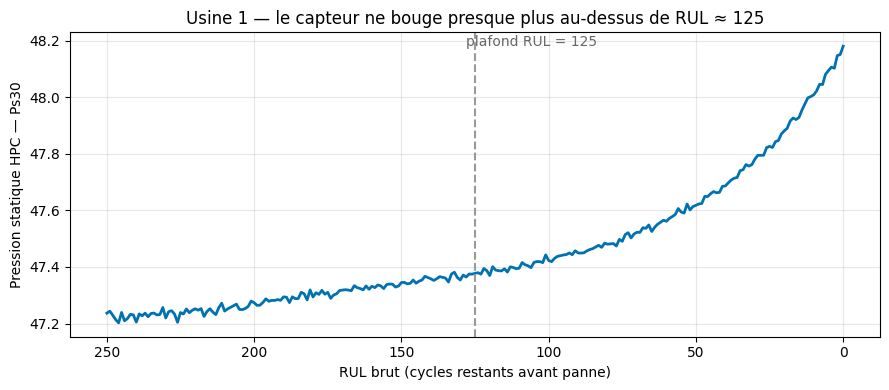

In [5]:
# RUL brut (sans plafond) sur l'Usine 1
rul_brut = (DF_U1_Train.groupby('machine_uid')['cycle'].transform('max')
            - DF_U1_Train['cycle'])

capteur_demo = 'Pression statique HPC — Ps30'
moyenne_par_rul = DF_U1_Train[capteur_demo].groupby(rul_brut).mean()
moyenne_par_rul = moyenne_par_rul[moyenne_par_rul.index <= 250]  # au-delà : trop peu de machines

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(moyenne_par_rul.index, moyenne_par_rul.values, color=outils.COULEURS['rf'], lw=2)
ax.axvline(125, color='#999999', ls='--', lw=1.5)
ax.text(128, moyenne_par_rul.max(), 'plafond RUL = 125', color='#666666')
ax.invert_xaxis()  # on lit de gauche (machine neuve) à droite (panne)
ax.set_xlabel('RUL brut (cycles restants avant panne)')
ax.set_ylabel(capteur_demo)
ax.set_title('Usine 1 — le capteur ne bouge presque plus au-dessus de RUL ≈ 125')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'justification_plafond_rul.png', dpi=120)
plt.show()

Lecture : à droite du trait (RUL > 125), la courbe est quasiment plate → aucun signal.
La dérive ne devient nette que dans les ~125 derniers cycles. Le plafond est donc justifié
par les données, pas seulement par la convention C-MAPSS.

## Split apprentissage / validation PAR MACHINE

**Piège corrigé de la V1.** Chaque machine est une trajectoire complète : deux cycles voisins
de la même machine sont presque identiques. Si on coupe le train par lignes (comme le fait
`validation_fraction` du HGB), le modèle retrouve en validation des cycles quasi identiques à
ceux qu'il a appris → score trop optimiste. Ici : 80 % des machines en apprentissage, 20 % en validation.

Le test officiel (machines tronquées + RUL vrai) reste l'examen final, jamais utilisé pour régler quoi que ce soit.

In [6]:
App_U1, Val_U1 = outils.separer_machines(DF_U1_Train)
App_U2, Val_U2 = outils.separer_machines(DF_U2_Train)

for nom, app, val in [("Usine 1", App_U1, Val_U1), ("Usine 2", App_U2, Val_U2)]:
    m_app = set(app['machine_uid'])
    m_val = set(val['machine_uid'])
    assert m_app.isdisjoint(m_val)  # aucune machine des deux côtés
    print(f"{nom} : {len(m_app)} machines en apprentissage ({len(app)} cycles), "
          f"{len(m_val)} en validation ({len(val)} cycles)")

Usine 1 : 160 machines en apprentissage (36278 cycles), 40 en validation (9073 cycles)
Usine 2 : 407 machines en apprentissage (92658 cycles), 102 en validation (22350 cycles)


## Choix des features — Usine 1

Même méthode qu'en V1, mais automatisée et traçable. Deux règles :

1. **Écart-type quasi nul** → le capteur ne bouge jamais sur cette usine, il ne peut rien
   apprendre au modèle (et sa corrélation est même incalculable → les "NaN" de la V1) ;
2. **Corrélation absolue avec le RUL < 0.05** → le capteur ne suit pas la dégradation.

Je garde aussi `cycle` : l'âge de la machine est une information légitime (en usine, on
connaît toujours le compteur d'heures). Les 3 réglages ne sont pas des features : ils
décrivent le régime de fonctionnement, pas l'usure (ils servent à l'Usine 2, voir plus bas).

In [7]:
capteurs = outils.capteurs_de(DF_U1_Train)

stds_U1 = App_U1[capteurs].std()
corr_U1 = App_U1[capteurs].corrwith(App_U1['RUL'])

bilan_U1 = pd.DataFrame({'ecart_type': stds_U1, 'corr_RUL': corr_U1})
bilan_U1['gardé'] = (bilan_U1['ecart_type'] > 1e-6) & (bilan_U1['corr_RUL'].abs() >= 0.05)
bilan_U1.sort_values('corr_RUL', key=abs, ascending=False)

,ecart_type,corr_RUL,gardé
Pression statique HPC — Ps30,2.934353e-01,-7.890348e-01,True
Température sortie LPT — T50,9.708547e+00,-7.605062e-01,True
Soutirage HPC — htBleed,1.701159e+00,-7.064001e-01,True
Température sortie LPC — T24,5.263598e-01,-6.800466e-01,True
Température sortie HPC — T30,6.625876e+00,-6.749825e-01,True
Vitesse corrigée fan — NRf,1.295043e-01,-5.994773e-01,True
Vitesse fan — Nf,1.294952e-01,-5.987701e-01,True
Vitesse cœur — Nc,2.074257e+01,-5.364276e-01,True
Vitesse corrigée cœur — NRc,1.757152e+01,-4.408359e-01,True
Rapport pression moteur — EPR,2.706792e-03,-3.379417e-01,True


In [8]:
Features_U1 = ['cycle'] + bilan_U1[bilan_U1['gardé']].index.tolist()
print(f"{len(Features_U1)} features retenues pour l'Usine 1 :")
for f in Features_U1:
    print(" -", f)

# Sauvegarde : tous les notebooks de modèles rechargeront CETTE liste
import json
with open(outils.DOSSIER_RESULTATS / 'features_usine1.json', 'w', encoding='utf-8') as f:
    json.dump(Features_U1, f, ensure_ascii=False, indent=1)

17 features retenues pour l'Usine 1 :
 - cycle
 - Température sortie LPC — T24
 - Température sortie HPC — T30
 - Température sortie LPT — T50
 - Pression bypass — P15
 - Pression sortie HPC — P30
 - Vitesse fan — Nf
 - Vitesse cœur — Nc
 - Rapport pression moteur — EPR
 - Pression statique HPC — Ps30
 - Ratio carburant/pression — phi
 - Vitesse corrigée fan — NRf
 - Vitesse corrigée cœur — NRc
 - Bypass Ratio — BPR
 - Soutirage HPC — htBleed
 - Débit refroid. HPT — W31
 - Débit refroid. LPT — W32


## Usine 2 — retrouver les 6 régimes et neutraliser leur bruit

L'Usine 2 (FD002 + FD004) tourne sur **6 régimes de fonctionnement**. Un même capteur saute
entre 6 plages de valeurs selon le régime : la dérive d'usure (quelques unités) est noyée dans
le "bruit de régime" (des centaines d'unités). D'où ma méthode de la V1, que je généralise ici :

1. identifier le régime de chaque cycle en arrondissant les 3 réglages (`ajouter_regime`) ;
2. centrer-réduire chaque capteur **par régime** (moyenne/écart-type calculés sur
   l'apprentissage uniquement) → il ne reste que l'écart à la normale *de ce régime*,
   c'est-à-dire le vrai signal de dégradation.

C'est un vrai point de différenciation avec l'approche "un seul scaler global" : un scaler
global mélange les 6 régimes et laisse tout le bruit.

In [9]:
DF_U2_Train = outils.ajouter_regime(DF_U2_Train)
DF_U2_Test = outils.ajouter_regime(DF_U2_Test)
App_U2 = outils.ajouter_regime(App_U2)
Val_U2 = outils.ajouter_regime(Val_U2)

comptage = DF_U2_Train['regime'].value_counts()
print(comptage)
assert len(comptage) == 6, "On doit retrouver exactement 6 régimes"
print("\n6 régimes retrouvés — chacun bien rempli")

regime
(42.0, 0.84, 100.0)    28853
(10.0, 0.25, 100.0)    17320
(0.0, 0.0, 100.0)      17282
(20.0, 0.7, 100.0)     17213
(35.0, 0.84, 100.0)    17199
(25.0, 0.62, 60.0)     17141
Name: count, dtype: int64

6 régimes retrouvés — chacun bien rempli


In [10]:
# Stats par régime sur l'APPRENTISSAGE uniquement (anti-fuite), puis normalisation partout
capteurs_U2 = outils.capteurs_de(DF_U2_Train)
moyennes_reg, ecarts_reg = outils.calculer_stats_regime(App_U2, capteurs_U2)

App_U2_norm = outils.normaliser_par_regime(App_U2, moyennes_reg, ecarts_reg, capteurs_U2)
Val_U2_norm = outils.normaliser_par_regime(Val_U2, moyennes_reg, ecarts_reg, capteurs_U2)

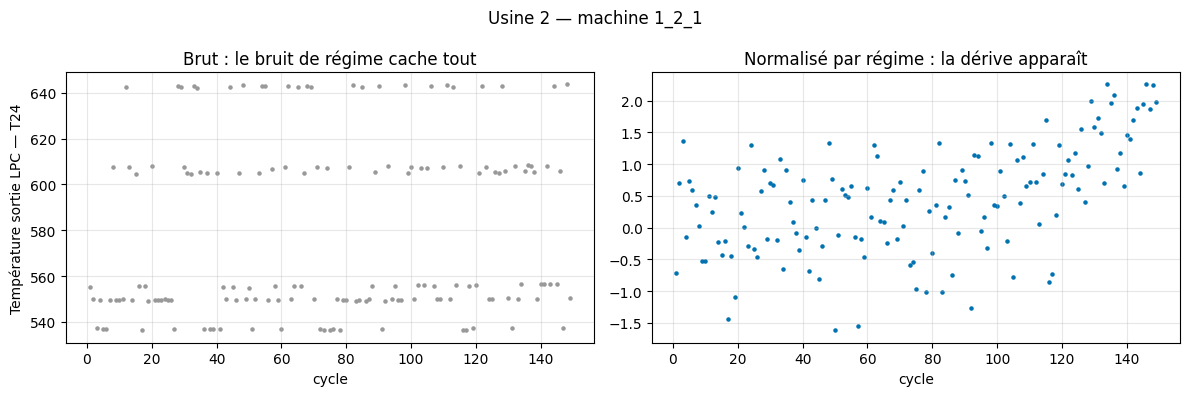

In [11]:
# La figure de la V1, refaite proprement : avant/après sur une machine
machine = App_U2['machine_uid'].iloc[0]
capteur = 'Température sortie LPC — T24'

brut = App_U2[App_U2['machine_uid'] == machine]
norm = App_U2_norm[App_U2_norm['machine_uid'] == machine]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(brut['cycle'], brut[capteur], s=5, color='#999999')
axes[0].set_title('Brut : le bruit de régime cache tout')
axes[1].scatter(norm['cycle'], norm[capteur], s=5, color=outils.COULEURS['rf'])
axes[1].set_title('Normalisé par régime : la dérive apparaît')
for ax in axes:
    ax.set_xlabel('cycle')
    ax.grid(alpha=0.3)
axes[0].set_ylabel(capteur)
plt.suptitle(f'Usine 2 — machine {machine}')
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'normalisation_regime_U2.png', dpi=120)
plt.show()

## Choix des features — Usine 2 (sur les capteurs normalisés)

Mêmes règles que l'Usine 1, mais appliquées **après** normalisation par régime. C'est important :
un capteur peut sembler inutile en brut (corrélation noyée) et devenir très informatif une fois
le bruit de régime retiré — et inversement, certains capteurs constants par régime ne portent rien.

In [12]:
stds_U2 = App_U2_norm[capteurs_U2].std()
corr_U2 = App_U2_norm[capteurs_U2].corrwith(App_U2_norm['RUL'])

bilan_U2 = pd.DataFrame({'ecart_type': stds_U2, 'corr_RUL': corr_U2})
bilan_U2['gardé'] = (bilan_U2['ecart_type'] > 1e-6) & (bilan_U2['corr_RUL'].abs() >= 0.05)
bilan_U2.sort_values('corr_RUL', key=abs, ascending=False)

,ecart_type,corr_RUL,gardé
Pression statique HPC — Ps30,9.999730e-01,-0.761277,True
Température sortie LPT — T50,9.999730e-01,-0.726033,True
Soutirage HPC — htBleed,9.999730e-01,-0.661395,True
Température sortie HPC — T30,9.999730e-01,-0.636827,True
Température sortie LPC — T24,9.999730e-01,-0.600345,True
Vitesse cœur — Nc,9.999730e-01,-0.523632,True
Vitesse corrigée fan — NRf,9.999730e-01,-0.500381,True
Vitesse fan — Nf,9.999730e-01,-0.499530,True
Vitesse corrigée cœur — NRc,9.999730e-01,-0.429617,True
Bypass Ratio — BPR,9.999730e-01,-0.223391,True


In [13]:
Features_U2 = ['cycle'] + bilan_U2[bilan_U2['gardé']].index.tolist()
print(f"{len(Features_U2)} features retenues pour l'Usine 2 :")
for f in Features_U2:
    print(" -", f)

with open(outils.DOSSIER_RESULTATS / 'features_usine2.json', 'w', encoding='utf-8') as f:
    json.dump(Features_U2, f, ensure_ascii=False, indent=1)

18 features retenues pour l'Usine 2 :
 - cycle
 - Température sortie LPC — T24
 - Température sortie HPC — T30
 - Température sortie LPT — T50
 - Pression bypass — P15
 - Pression sortie HPC — P30
 - Vitesse fan — Nf
 - Vitesse cœur — Nc
 - Rapport pression moteur — EPR
 - Pression statique HPC — Ps30
 - Ratio carburant/pression — phi
 - Vitesse corrigée fan — NRf
 - Vitesse corrigée cœur — NRc
 - Bypass Ratio — BPR
 - Richesse carburant — farB
 - Soutirage HPC — htBleed
 - Débit refroid. HPT — W31
 - Débit refroid. LPT — W32


## Bilan de la préparation

Ce qui part vers les notebooks de modèles :

| Élément | Usine 1 | Usine 2 |
|---|---|---|
| Régimes | 1 (rien à faire) | 6 → normalisation par régime |
| Features | `resultats/features_usine1.json` | `resultats/features_usine2.json` |
| Cible régression | `RUL` plafonné à 125 | idem |
| Cible classification | `at_risk` (RUL ≤ 30, ~14 % de positifs) | idem |
| Split | 80/20 **par machine**, graine 42 | idem |

Chaque notebook de modèle (02 baseline, 03 Random Forest, 04 HGB, 05 LSTM) refait exactement
cette préparation via `outils_mspr` et s'évalue sur le test officiel de la même façon →
le notebook 06 peut tout comparer.